In [ ]:
import pandas as pd
df = pd.read_csv("45_traffic_accidents.csv")
df.head()

,id,speed_kmh,weather,light_condition,road_type,vehicles_involved,severity_1to3
0,1,95,fog,night,rural,1,3
1,2,60,fog,day,rural,1,3
2,3,70,fog,night,rural,3,3
3,4,53,fog,day,rural,2,3
4,5,88,clear,night,urban,1,2


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 1100 non-null   int64 
 1   speed_kmh          1100 non-null   int64 
 2   weather            1100 non-null   object
 3   light_condition    1100 non-null   object
 4   road_type          1100 non-null   object
 5   vehicles_involved  1100 non-null   int64 
 6   severity_1to3      1100 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 60.3+ KB


,id,speed_kmh,vehicles_involved,severity_1to3
count,1100.000000,1100.000000,1100.000000,1100.000000
mean,550.500000,58.707273,2.500000,2.069091
std,317.686953,24.144578,1.130679,0.951389
min,1.000000,10.000000,1.000000,1.000000
25%,275.750000,42.000000,1.000000,1.000000
50%,550.500000,59.000000,3.000000,2.000000
75%,825.250000,75.000000,4.000000,3.000000
max,1100.000000,160.000000,4.000000,3.000000


In [ ]:
df.isnull().sum()

,0
id,0
speed_kmh,0
weather,0
light_condition,0
road_type,0
vehicles_involved,0
severity_1to3,0


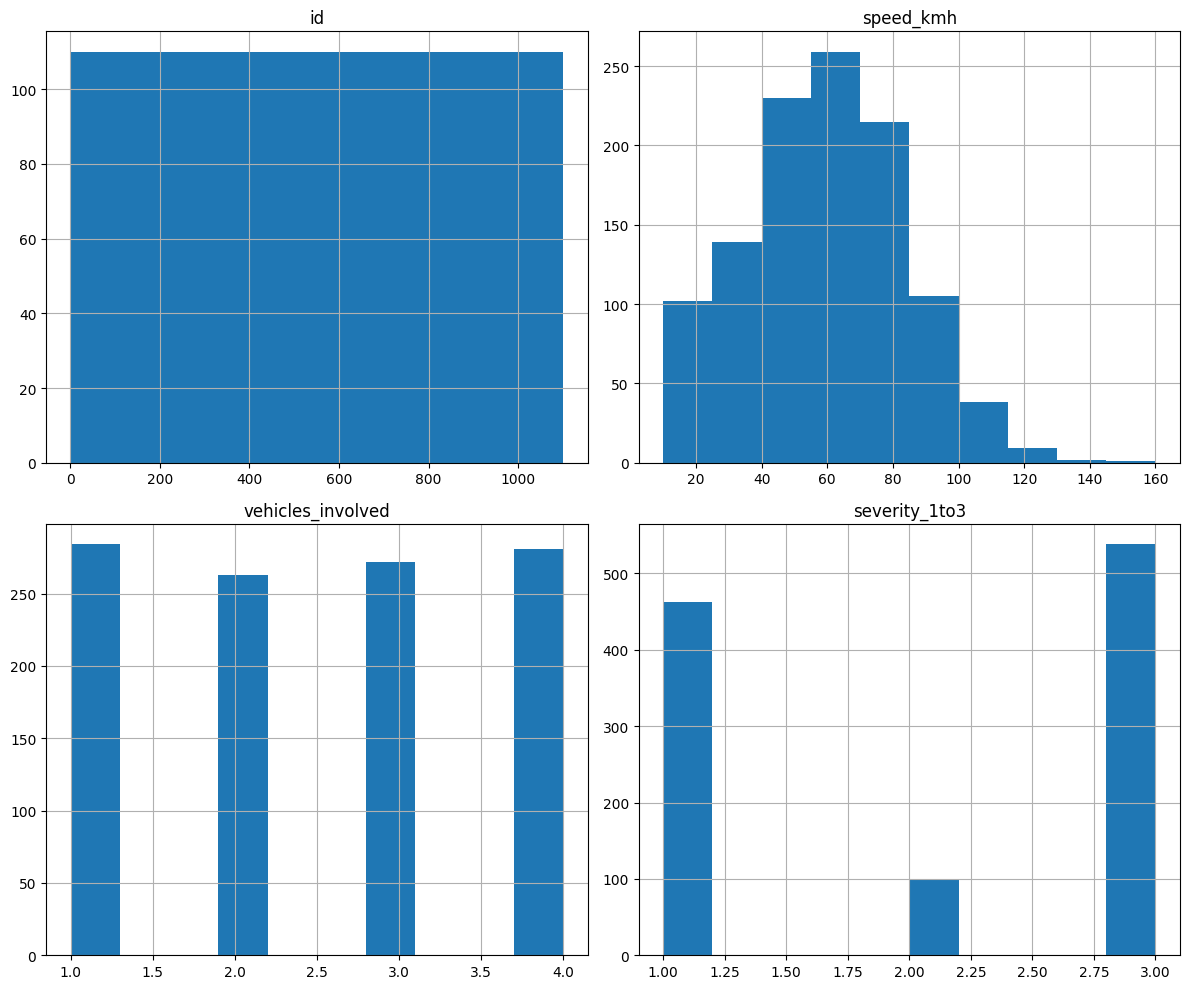

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

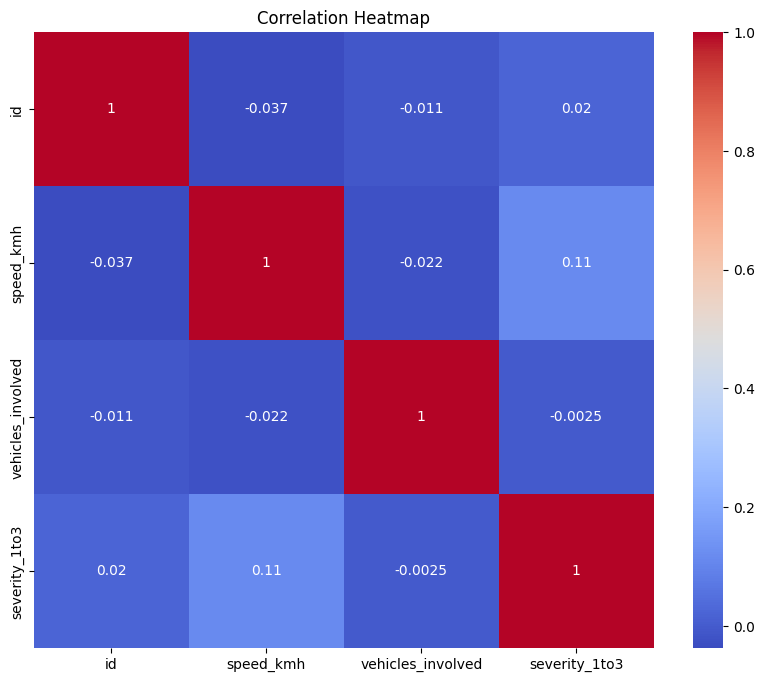

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

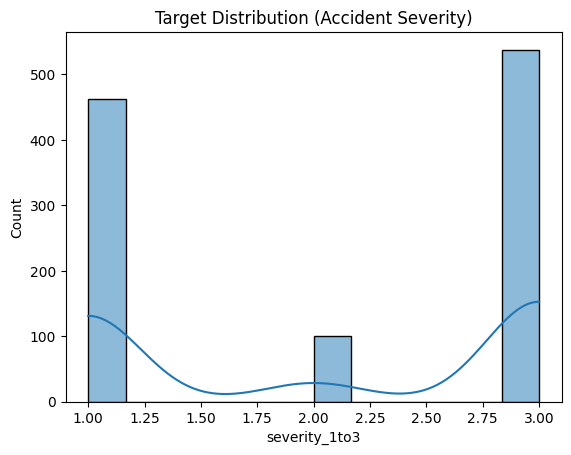

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["severity_1to3"], kde=True)
plt.title("Target Distribution (Accident Severity)")
plt.show()

In [ ]:
X = df.drop("severity_1to3", axis=1)
y = df["severity_1to3"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.021272727272727273
RMSE: 0.10502813475878306
R2 Score: 0.9878047465679892


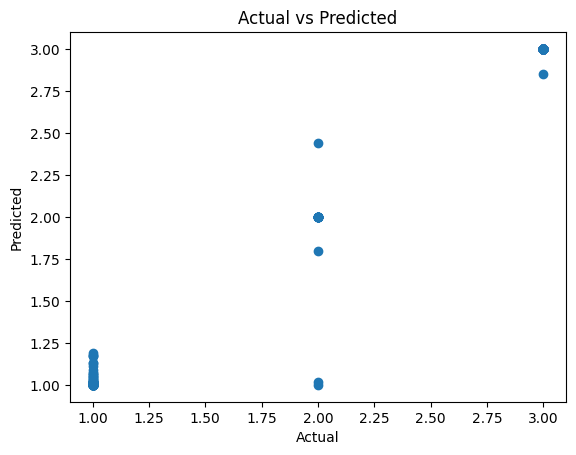

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

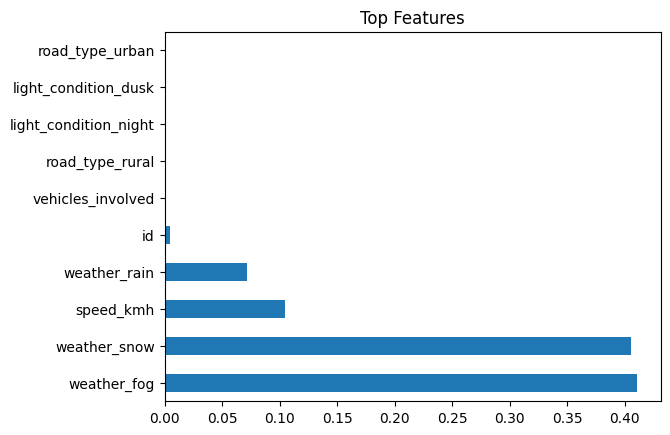

In [ ]:
import pandas as pd

importance = rf.feature_importances_
feat_imp = pd.Series(importance, index=X.columns)

feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top Features")
plt.show()

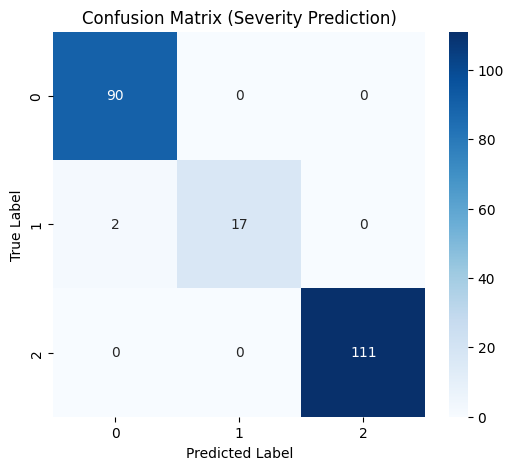

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Round predictions to nearest integer and ensure they are within valid range (1-3)
y_pred_rounded = np.round(y_pred).astype(int)
y_pred_rounded[y_pred_rounded < 1] = 1
y_pred_rounded[y_pred_rounded > 3] = 3

cm = confusion_matrix(y_test, y_pred_rounded)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Severity Prediction)")
plt.show()